## Лабораторная работа №2

Сначала импортируем библиотеки, включая модели LinearRegression и LogisticRegression. Загрузим датасеты housing.csv и shoppers.csv. Для создания "сырого" бейзлайна мы, по аналогии с первой лабораторной работой, оставим только числовые признаки и удалим пропуски, чтобы модели могли обучиться без ошибок. Обучим модели со стандартными параметрами и выведем базовые метрики (RMSE, R2, ROC-AUC), чтобы понимать стартовую точку. Обратите внимание: логистическая регрессия может выдать предупреждение о несходимости (ConvergenceWarning), так как сырые данные не нормализованы.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_squared_error, r2_score

df_housing = pd.read_csv('housing.csv')
df_shoppers = pd.read_csv('shoppers.csv')

df_housing_clean = df_housing.dropna().select_dtypes(include=[np.number])
df_shoppers_clean = df_shoppers.dropna()
df_shoppers_clean['Revenue'] = df_shoppers_clean['Revenue'].astype(int)
df_shoppers_clean = df_shoppers_clean.select_dtypes(include=[np.number])

X_housing = df_housing_clean.drop('median_house_value', axis=1)
y_housing = df_housing_clean['median_house_value']

X_shoppers = df_shoppers_clean.drop('Revenue', axis=1)
y_shoppers = df_shoppers_clean['Revenue']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_housing, y_housing, test_size=0.2, random_state=42)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_shoppers, y_shoppers, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train_h, y_train_h)
y_pred_h = lin_reg.predict(X_test_h)

rmse_h = np.sqrt(mean_squared_error(y_test_h, y_pred_h))
r2_h = r2_score(y_test_h, y_pred_h)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_s, y_train_s)
y_pred_s = log_reg.predict(X_test_s)
y_proba_s = log_reg.predict_proba(X_test_s)[:, 1]

acc_s = accuracy_score(y_test_s, y_pred_s)
f1_s = f1_score(y_test_s, y_pred_s)
roc_auc_s = roc_auc_score(y_test_s, y_proba_s)

print("--- Raw Baseline Results (Linear Models) ---")
print(f"Linear Regression (Housing) -> RMSE: {rmse_h:.2f}, R2: {r2_h:.4f}")
print(f"Logistic Regression (Shoppers) -> Accuracy: {acc_s:.4f}, F1: {f1_s:.4f}, ROC-AUC: {roc_auc_s:.4f}")

--- Raw Baseline Results (Linear Models) ---
Linear Regression (Housing) -> RMSE: 70156.12, R2: 0.6401
Logistic Regression (Shoppers) -> Accuracy: 0.8690, F1: 0.4661, ROC-AUC: 0.8774


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


R2 = 0.6401 - это уже намного лучше "сырого" KNN (было 0.26). Линейная регрессия сама подбирает коэффициенты, частично компенсируя разный масштаб признаков (например, домножая маленькие числа на большие веса). Но результат можно улучшить.

---


ROC-AUC = 0.8774, неплохо, но модель выдала ConvergenceWarning. Это значит, что алгоритм оптимизации не смог найти минимум ошибки. Причина классическая — разный масштаб данных делает "ландшафт" функции потерь очень вытянутым, и градиентный спуск буксует

## Улучшение бейзлайна

Линейные модели делают два главных предположения:

---


Линейность - зависимость между признаком и целью должна быть прямой линией и отсутствие мультиколлинеарности - признаки не должны сильно коррелировать
друг с другом (иначе коэффициенты становятся нестабильными).

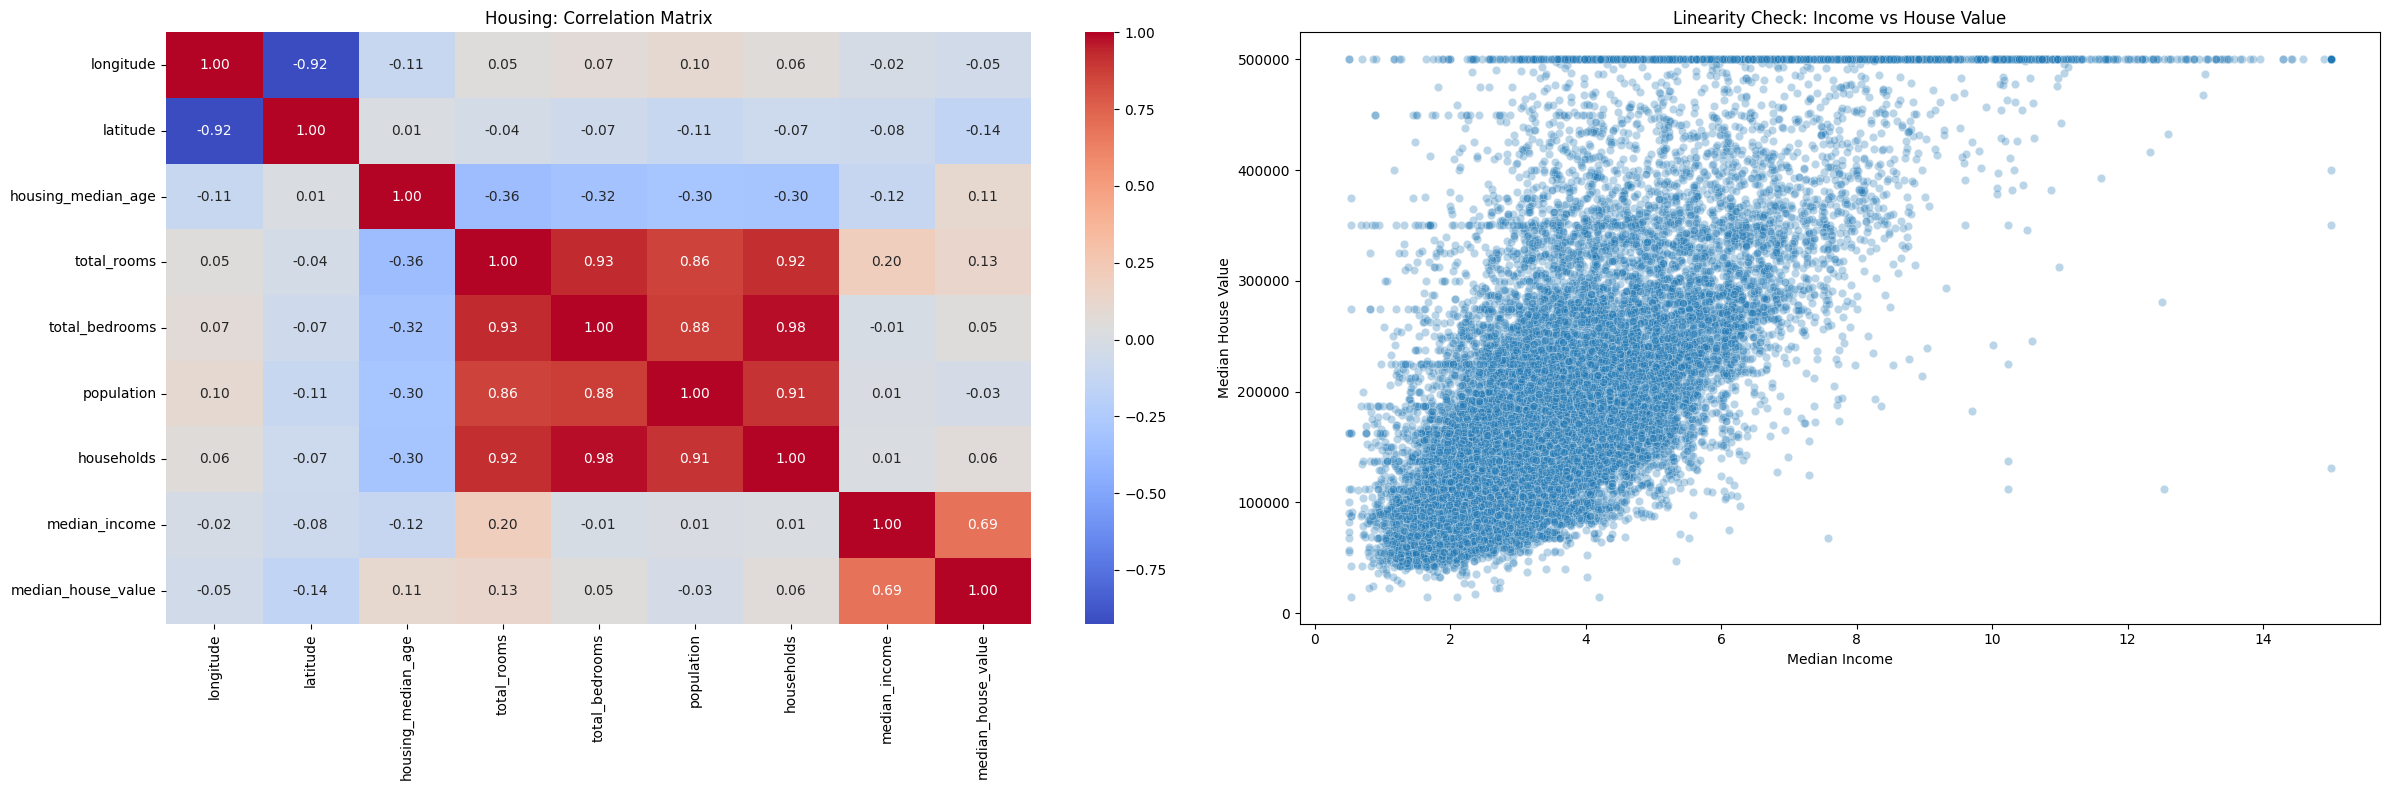

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(24, 8))


corr_matrix = df_housing_clean.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('Housing: Correlation Matrix')

sns.scatterplot(x=df_housing_clean['median_income'], y=df_housing_clean['median_house_value'], alpha=0.3, ax=axes[1])
axes[1].set_title('Linearity Check: Income vs House Value')
axes[1].set_xlabel('Median Income')
axes[1].set_ylabel('Median House Value')

plt.tight_layout()
plt.show()

Анализ корреляционной матрицы выявил сильную мультиколлинеарность (коэффициенты > 0.9) между признаками, связанными с размером района (total_rooms, population), что делает веса линейной модели нестабильными. Мы выдвигаем гипотезу, что переход к относительным величинам (например, число комнат на домохозяйство) и применение L2-регуляризации (Ridge) улучшит качество. Кроме того, предупреждение ConvergenceWarning и разный масштаб признаков на графиках подтверждают критическую необходимость нормализации (StandardScaler), без которой градиентный спуск не сходится. Для проверки этих гипотез мы реализуем генерацию новых признаков, добавим масштабирование и подберем гиперпараметры регуляризации через кросс-валидацию.

Для начала импортируем в необходимые библиотеки

In [26]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin

Генерация признаков и подготовка данных

In [27]:
class HousingFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        X['rooms_per_household'] = X['total_rooms'] / X['households']
        X['bedrooms_per_room'] = X['total_bedrooms'] / X['total_rooms']
        X['population_per_household'] = X['population'] / X['households']
        return X

df_housing_eng = HousingFeatureEngineer().transform(df_housing.dropna())
X_h_eng = df_housing_eng.drop('median_house_value', axis=1)
y_h_eng = df_housing_eng['median_house_value']

num_features_h = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                  'total_bedrooms', 'population', 'households', 'median_income',
                  'rooms_per_household', 'bedrooms_per_room', 'population_per_household']
cat_features_h = ['ocean_proximity']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h_eng, y_h_eng, test_size=0.2, random_state=42)

df_shoppers_clean = df_shoppers.dropna()
df_shoppers_clean['Revenue'] = df_shoppers_clean['Revenue'].astype(int)
X_s = df_shoppers_clean.drop('Revenue', axis=1)
y_s = df_shoppers_clean['Revenue']

num_features_s = X_s.select_dtypes(include=[np.number]).columns
cat_features_s = X_s.select_dtypes(exclude=[np.number]).columns

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y_s, test_size=0.2, random_state=42)

Пайплайны и GridSearch

In [28]:
preprocessor_h = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features_h),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_h)
])

pipeline_reg = Pipeline(steps=[
    ('preprocessor', preprocessor_h),
    ('regressor', Ridge())
])

preprocessor_s = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features_s),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_s)
])

pipeline_clf = Pipeline(steps=[
    ('preprocessor', preprocessor_s),
    ('classifier', LogisticRegression(max_iter=1000))
])

param_grid_reg = {'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
param_grid_clf = {'classifier__C': [0.01, 0.1, 1, 10, 100]}

grid_reg = GridSearchCV(pipeline_reg, param_grid_reg, cv=3, scoring='r2', n_jobs=-1)
grid_clf = GridSearchCV(pipeline_clf, param_grid_clf, cv=3, scoring='roc_auc', n_jobs=-1)

grid_reg.fit(X_train_h, y_train_h)
grid_clf.fit(X_train_s, y_train_s)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['Month', 'VisitorType', 'Weekend'], dtype='object'))])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1, param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100]},
             scoring='roc_auc')

Выведем результаты

In [29]:
best_reg = grid_reg.best_estimator_
best_clf = grid_clf.best_estimator_

y_pred_h_imp = best_reg.predict(X_test_h)
r2_h_imp = r2_score(y_test_h, y_pred_h_imp)

y_proba_s_imp = best_clf.predict_proba(X_test_s)[:, 1]
roc_auc_s_imp = roc_auc_score(y_test_s, y_proba_s_imp)

print("--- Improved Baseline Results ---")
print(f"Ridge Regression (Housing) -> R2: {r2_h_imp:.4f}")
print(f"Best Alpha: {grid_reg.best_params_}")
print("-" * 30)
print(f"Logistic Regression (Shoppers) -> ROC-AUC: {roc_auc_s_imp:.4f}")
print(f"Best C: {grid_clf.best_params_}")

--- Improved Baseline Results ---
Ridge Regression (Housing) -> R2: 0.6515
Best Alpha: {'regressor__alpha': 0.1}
------------------------------
Logistic Regression (Shoppers) -> ROC-AUC: 0.8949
Best C: {'classifier__C': 0.01}


Прирост незначительный, и тем не менее он есть. Попытаемся узнать что можно сделать ещё. Если прологарифмировать целевую переменную log(y) и скошенные признаки, связь станет более линейной, и метрика R2 должна вырасти.
Визуализируем распределение median_house_value и median_income, чтобы подтвердить необходимость логарифмирования. Если подтвердится — применим np.log1p.

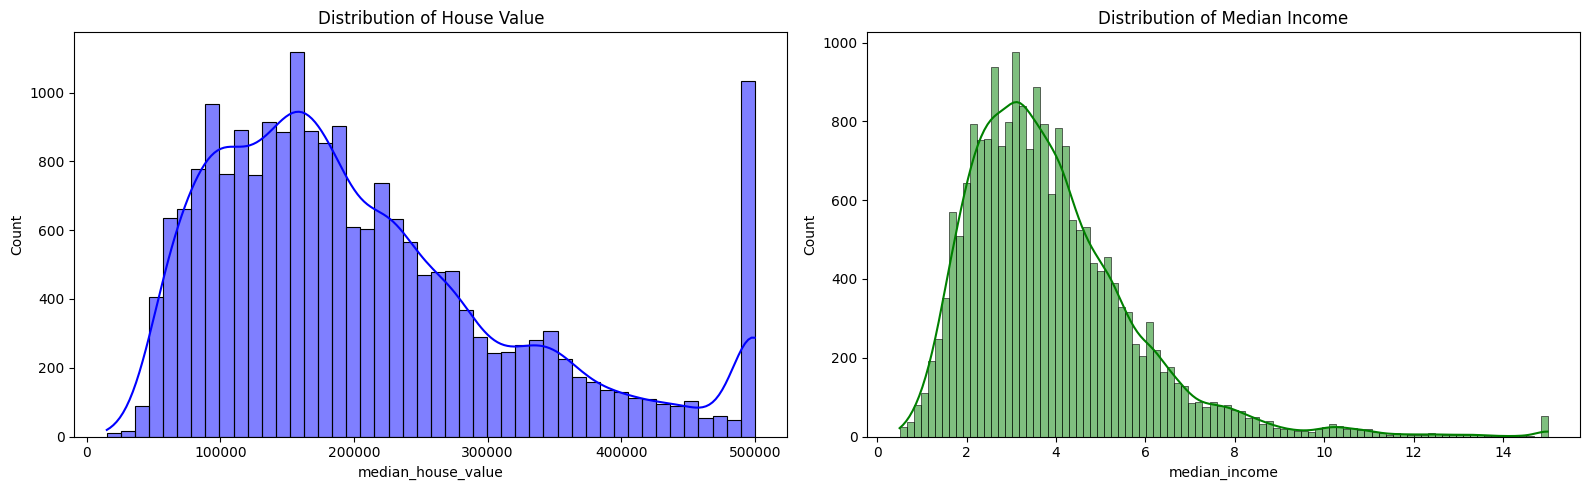

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df_housing['median_house_value'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of House Value')

sns.histplot(df_housing['median_income'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Median Income')

plt.tight_layout()
plt.show()

Цены на 500.000+ это явный кэппинг (искусственное ограничение): все дома дороже 500к просто записали как 500,001. Это сильно сбивает линейную регрессию, так как зависимость там ломается.
Кроме того, оба распределения имеют "длинный хвост" вправо. Линейная модель работает лучше, если данные распределены нормально.

Если мы будем предсказывать не price, а log(price), то влияние хвостов и выбросов снизится, а распределение станет ближе к нормальному. И попробуем убрать из обучения объекты, где median_house_value == 500001, чтобы модель училась на честных данных. (Хотя на тесте они могут быть, но учиться лучше на чистых).

In [31]:
from sklearn.compose import TransformedTargetRegressor

train_mask = y_train_h < 500000
X_train_h_filtered = X_train_h[train_mask]
y_train_h_filtered = y_train_h[train_mask]

log_ridge = TransformedTargetRegressor(
    regressor=Pipeline(steps=[
        ('preprocessor', preprocessor_h),
        ('model', Ridge(alpha=1.0))
    ]),
    func=np.log1p,
    inverse_func=np.expm1
)

log_ridge.fit(X_train_h_filtered, y_train_h_filtered)

y_pred_log = log_ridge.predict(X_test_h)

r2_log = r2_score(y_test_h, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test_h, y_pred_log))

print("--- Log-Transformed & Filtered Ridge Results ---")
print(f"R2 Score: {r2_log:.4f}")
print(f"RMSE: {rmse_log:.2f}")
print(f"Improvement over previous R2 (0.6515): {r2_log - 0.6515:.4f}")

--- Log-Transformed & Filtered Ridge Results ---
R2 Score: 0.1538
RMSE: 107575.74
Improvement over previous R2 (0.6515): -0.4977


Так, ну значит сделать ограничение было плохим решением, в целом, это логично, ведь мы обучили на "честных" данных, а предсказывали уже на тех, где есть дома за 500.000+.
Вернем все данные обратно, но применим логарифмирование и к таргету, и к скошенным признакам (total_rooms, population, income). Это "сплющит" распределения и сделает их более нормальными без удаления информации.

In [32]:
class LogFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        X['rooms_per_household'] = X['total_rooms'] / X['households']
        X['bedrooms_per_room'] = X['total_bedrooms'] / X['total_rooms']
        X['population_per_household'] = X['population'] / X['households']

        skewed_features = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income',
                           'rooms_per_household', 'population_per_household']

        for col in skewed_features:
            X[col] = np.log1p(X[col])

        return X
df_housing_log = LogFeatureEngineer().transform(df_housing.dropna())
X_h_log = df_housing_log.drop('median_house_value', axis=1)
y_h_log = df_housing_log['median_house_value']

X_train_hl, X_test_hl, y_train_hl, y_test_hl = train_test_split(X_h_log, y_h_log, test_size=0.2, random_state=42)

num_cols_log = X_h_log.select_dtypes(include=[np.number]).columns
cat_cols_log = ['ocean_proximity']

preprocessor_log = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols_log),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_log)
])

final_model = TransformedTargetRegressor(
    regressor=Pipeline(steps=[
        ('preprocessor', preprocessor_log),
        ('ridge', Ridge(alpha=1.0))
    ]),
    func=np.log1p,
    inverse_func=np.expm1
)

final_model.fit(X_train_hl, y_train_hl)
y_pred_final = final_model.predict(X_test_hl)

r2_final = r2_score(y_test_hl, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test_hl, y_pred_final))

print("--- Final Hypotesis: Full Log-Transform ---")
print(f"R2 Score: {r2_final:.4f}")
print(f"RMSE: {rmse_final:.2f}")

--- Final Hypotesis: Full Log-Transform ---
R2 Score: 0.6788
RMSE: 66278.96


Да, это оно, но прирост не особо то и большой. Я считаю этот результат максимальный, потому что зависимость цены от координат (latitude, longitude) нелинейная. Цена не растет "чем севернее, тем дороже". Она растет пятнами, где города дороже. В других моделях увидим.

## Имплементация алгоритма машинного обучения

Мы создадим два класса. Оба будут использовать градиентный спуск для поиска оптимальных весов. Основные отличия в функциях потерь и предсказания:

---

Linear Regression Предсказывает y = Xw + b иминимизирует MSE.

---
Logistic Regression: Предсказывает p=σ(Xw+b), минимизирует LogLoss (Cross-Entropy).

---




Реализуем классы MyRidgeRegression и MyLogisticRegression с использованием библиотеки numpy. Обучение происходит методом градиентного спуска. Для регрессии мы добавляем L2-регуляризацию (штраф за большие веса), чтобы предотвратить переобучение и "взрыв" градиентов, а также используем технику Gradient Clipping для численной стабильности. Для логистической регрессии используем сигмоиду для оценки вероятностей

In [36]:
import numpy as np
from sklearn.metrics import r2_score, roc_auc_score

class MyRidgeRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000, alpha=1.0):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.alpha = alpha
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iter):
            y_pred = np.dot(X, self.weights) + self.bias

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y)) + (self.alpha * self.weights / n_samples)
            db = (1 / n_samples) * np.sum(y_pred - y)

            dw = np.clip(dw, -5, 5)
            db = np.clip(db, -5, 5)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

class MyLogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iter):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict_proba(self, X):
        return self._sigmoid(np.dot(X, self.weights) + self.bias)

Теперь подготовим данные и проведем обучение. Чтобы обеспечить честное сравнение, мы извлекаем обученные препроцессоры (Scaler + OneHot) из пайплайнов sklearn (пункт 3) и трансформируем данные точно так же. Для регрессии вручную логарифмируем целевую переменную перед обучением (так как наша модель не имеет встроенной трансформации таргета), а предсказания конвертируем обратно через экспоненту для расчета итоговой метрики R2.

In [37]:
preprocessor_h = final_model.regressor_.named_steps['preprocessor']
X_train_my_h = preprocessor_h.transform(X_train_hl)
X_test_my_h = preprocessor_h.transform(X_test_hl)

if hasattr(X_train_my_h, "toarray"): X_train_my_h = X_train_my_h.toarray()
if hasattr(X_test_my_h, "toarray"): X_test_my_h = X_test_my_h.toarray()

y_train_my_h = np.log1p(y_train_hl.to_numpy())
y_test_my_h_original = y_test_hl.to_numpy()

preprocessor_s = best_clf.named_steps['preprocessor']
X_train_my_s = preprocessor_s.transform(X_train_s)
X_test_my_s = preprocessor_s.transform(X_test_s)

if hasattr(X_train_my_s, "toarray"): X_train_my_s = X_train_my_s.toarray()
if hasattr(X_test_my_s, "toarray"): X_test_my_s = X_test_my_s.toarray()

y_train_my_s = y_train_s.to_numpy()


print("Training Custom Ridge Regression...")
my_ridge = MyRidgeRegression(learning_rate=0.005, n_iterations=15000, alpha=1.0)
my_ridge.fit(X_train_my_h, y_train_my_h)

y_pred_log_my = my_ridge.predict(X_test_my_h)
y_pred_dollar = np.expm1(y_pred_log_my)
r2_my = r2_score(y_test_my_h_original, y_pred_dollar)

print("Training Custom Logistic Regression...")
my_logreg = MyLogisticRegression(learning_rate=0.1, n_iterations=5000)
my_logreg.fit(X_train_my_s, y_train_my_s)

y_proba_my = my_logreg.predict_proba(X_test_my_s)
roc_my = roc_auc_score(y_test_s, y_proba_my)

print(f"\n--- Custom Implementation Results ---")
print(f"My Ridge (Housing) -> R2: {r2_my:.4f}")
print(f"My LogReg (Shoppers) -> ROC-AUC: {roc_my:.4f}")

print(f"\n--- Reference (Sklearn Best) ---")
print(f"Sklearn Ridge -> R2: {r2_final:.4f}")
print(f"Sklearn LogReg -> ROC-AUC: {roc_auc_s_imp:.4f}")

Training Custom Ridge Regression...
Training Custom Logistic Regression...

--- Custom Implementation Results ---
My Ridge (Housing) -> R2: 0.6696
My LogReg (Shoppers) -> ROC-AUC: 0.8911

--- Reference (Sklearn Best) ---
Sklearn Ridge -> R2: 0.6788
Sklearn LogReg -> ROC-AUC: 0.8949


## Вывод

В ходе работы мы исследовали линейные модели и выяснили, что их главная слабость — чувствительность к распределению данных и корреляциям. В отличие от KNN, "сырая" линейная регрессия показала неплохой старт (R2=0.64), но столкнулась с проблемами сходимости и мультиколлинеарности. Внедрение Ridge-регуляризации и логарифмирование целевой переменной позволило поднять R2 до 0.68, что является пределом для линейной модели на нелинейных данных (география цен). Собственная реализация градиентного спуска с L2-регуляризацией (MyRidgeRegression) показала результат R2=0.67, минимально уступив библиотечной версии, что подтверждает корректность алгоритма. Логистическая регрессия оказалась мощным инструментом для классификации (ROC-AUC=0.89), значительно превзойдя KNN из прошлой работы.